## Note: This project will take live data from yahoo finance. Please do not run if it is evening or weekend (instead see existing cell output as shown) - as there will be no data from yahoo finance (as stock exchange is closed then) and result in an empty dataset.

Background on Project and ARIMA:  
I have enjoyed crypto and stock trading and always wondered if there was a way to incorporate machine learning. I came across ARIMA model for time series forecasting.
Below is a short summary of ARIMA model. Note: I have referenced the link here for this and added my own understanding as well:  
https://machinelearningmastery.com/arima-for-time-series-forecasting-with-python/
  
ARIMA - Autoregressive(AR) Integrated(I) Moving(M) Average(A) Model.   
This is a model for analyzing and forecasting time series data. This can be explained by breaking it down.  
AR: Autogreggesion - It does so by using a dependent relationship between an observation and some previous (lagged) observations.   
I: Integration - The model uses differencing of raw observations in order to make time series stationary. Essentially a stationary time series is one whose properties don't depend on the time at which the series is observed. Ex. with seasonality - temperature, humidity etc would vary at different times of observation. The same is true with stock price - it would vary at different times of observation (constant changes in stock price).   
MA: Moving Average - Uses dependency between ab observation and a residual error from a moving average model applied to lagged observations. Essentially - the avergae of all lagged data is constantly moving as new data is being generated, so a dependency between observation and residual error from moving average is applied to lagged observations.
  
The above explanation breakdowns of the term ARIMA all have parameters: p, d, q  
p: lag order - # of time lags (lagged observations)  
d: degree of differencing - # of times the data have had past values subtracted   
q: order of moving average - size of the moving average window

The following guides were referenced for this project:
https://machinelearningmastery.com/grid-search-arima-hyperparameters-with-python/
https://towardsdatascience.com/time-series-forecasting-predicting-stock-prices-using-an-arima-model-2e3b3080bd70
https://towardsdatascience.com/stock-market-analysis-using-arima-8731ded2447a
https://towardsdatascience.com/an-introduction-to-time-series-analysis-with-arima-a8b9c9a961fb

In [1]:
pip install yfinance --user

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Can check price of any stock as long as ticker is available on yahoo finance
#Can replace 'TSLA' with ticker symmbol of choice
import yfinance as yf
tesla = yf.Ticker("TSLA")
df = tesla.history(period='1d', interval="1m")
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2021-12-06 09:30:00-05:00,1000.000000,1000.000000,1000.000000,1000.000000,1700387,0,0
2021-12-06 09:31:00-05:00,997.789978,999.994995,988.789978,988.989990,334502,0,0
2021-12-06 09:32:00-05:00,988.945496,989.460022,982.350098,982.850403,273963,0,0
2021-12-06 09:33:00-05:00,988.000000,988.669983,985.457703,986.799988,261562,0,0
2021-12-06 09:34:00-05:00,980.000000,980.479980,975.059998,975.200012,400724,0,0


In [3]:
#Retain only the 'Low' column as we are interested in buying if price drops below 
df = df[['Low']]
df.head()

,Low
Datetime,
2021-12-06 09:30:00-05:00,1000.000000
2021-12-06 09:31:00-05:00,988.789978
2021-12-06 09:32:00-05:00,982.350098
2021-12-06 09:33:00-05:00,985.457703
2021-12-06 09:34:00-05:00,975.059998


In [4]:
#Retain only time. Using only last day, so don't need the date and year
import pandas as pd
df['date'] = pd.to_datetime(df.index).time
df.set_index('date', inplace=True)
df.tail()

,Low
date,
13:15:00,1007.010010
13:16:00,1008.688477
13:17:00,1008.000427
13:18:00,1007.000671
13:19:55,1006.669983


In [5]:
#Generate X and y populated with date and Low value price respectively. 
X = df.index.values
y = df['Low'].values

#Split the train/test at 10%. 90% train/10%test data. 
#Cannot use train_test_split function here as X is not a feature matrix.
split = int(0.10*len(df))
X_train = X[:-split]
y_train = y[:-split]
X_test = X[-split:]
y_test = y[-split:]

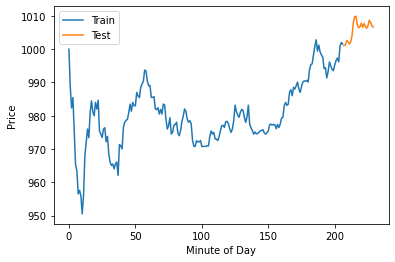

In [6]:
#Plot the data
import matplotlib.pyplot as plt
plt.plot(range(0,len(y_train)),y_train, label='Train')
plt.plot(range(len(y_train),len(y)),y_test,label='Test')
plt.legend()
plt.xlabel('Minute of Day') #0 indicates 9:30AM Eastern Time when market opens. All numbers are minutes after that.
plt.ylabel('Price')
plt.show()

The below grid search was the most complex part of this project. Though not required, it is good to do it to get the best results. The below cell was mostly not coded by me (Dr.Pauchard mentioned to note this as appropriate) and was modified using the below article:  
https://machinelearningmastery.com/grid-search-arima-hyperparameters-with-python
Though a layout was provided, refactoring the grid search required full understanding, reproducting the search, choosing the correct hyperparameters, identifying the best ones and using those in the search in an autmated fashion (ex. using best_cfg) to identify/store and carry forward the best hyperparameter values

In [7]:
# Grid search to identify best ARIMA parameters for time series
import warnings
from math import sqrt
from pandas import datetime
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# evaluate an ARIMA model for a given order (p,d,q)
def evaluate_arima_model(X, arima_order):
    # prepare training dataset
    train_size = int(len(X) * 0.9) #90% data in training set.
    train, test = X[0:train_size], X[train_size:]
    history = [x for x in train]
    # make predictions
    predictions = list()
    for t in range(len(test)):
        model = ARIMA(history, order=arima_order)
        model_fit = model.fit()
        yhat = model_fit.forecast()[0]
        predictions.append(yhat)
        history.append(test[t])
    # calculate out of sample error
    rmse = sqrt(mean_squared_error(test, predictions))
    return rmse

# evaluate combinations of p, d and q values for an ARIMA model
def evaluate_models(dataset, p_values, d_values, q_values):
    global best_cfg
    dataset = dataset.astype('float32')
    best_score, best_cfg = float("inf"), None
    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p,d,q)
                try:
                    rmse = evaluate_arima_model(dataset, order)
                    if rmse < best_score:
                        best_score, best_cfg = rmse, order
                        best_param=best_cfg
                    print('ARIMA%s RMSE=%.3f' % (order,rmse))
                except:
                    continue
    print('Best ARIMA%s RMSE=%.3f' % (best_cfg, best_score))

# load dataset
def parser(x):
    return datetime.strptime('190'+x, '%Y-%m')

# evaluate best combination amongst variety of parameters for p,d,q values.
p_values = [0, 1, 2, 4, 6]
d_values = range(0, 2)
q_values = range(0, 2)
warnings.filterwarnings("ignore")
evaluate_models(y, p_values, d_values, q_values)

<ipython-input-7-cdd4420b9369>:4: FutureWarning: The pandas.datetime class is deprecated and will be removed from pandas in a future version. Import from datetime module instead.
  from pandas import datetime


ARIMA(0, 0, 0) RMSE=24.393
ARIMA(0, 0, 1) RMSE=13.009
ARIMA(0, 1, 0) RMSE=1.371
ARIMA(0, 1, 1) RMSE=1.318
ARIMA(1, 0, 0) RMSE=1.509
ARIMA(1, 0, 1) RMSE=1.494
ARIMA(1, 1, 0) RMSE=1.323
ARIMA(1, 1, 1) RMSE=1.376
ARIMA(2, 0, 0) RMSE=1.503
ARIMA(2, 0, 1) RMSE=1.715
ARIMA(2, 1, 0) RMSE=1.325
ARIMA(2, 1, 1) RMSE=1.354
ARIMA(4, 0, 0) RMSE=1.771
ARIMA(4, 0, 1) RMSE=1.867
ARIMA(4, 1, 0) RMSE=1.519
ARIMA(4, 1, 1) RMSE=1.516
ARIMA(6, 0, 0) RMSE=1.914
ARIMA(6, 0, 1) RMSE=1.910
ARIMA(6, 1, 0) RMSE=1.535
ARIMA(6, 1, 1) RMSE=1.689
Best ARIMA(0, 1, 1) RMSE=1.318


In [8]:
#Fitting to an ARIMA model
from sklearn.metrics import mean_squared_error
model = ARIMA(y_train, order= best_cfg).fit()
forecast = model.forecast(steps=1)[0]

In [9]:
#forecast will predict the next value of the stock price. 
print(f'Real data for time 0 (last data point available): {y_train[len(y_train)-1]}')
print(f'Real data for time 1 (first data point in test set): {y_test[0]}')
print(f'Pred data for time 1 (first data point predicted): {forecast}')


Real data for time 0 (last data point available): 1001.5473022460938
Real data for time 1 (first data point in test set): 1001.0800170898438
Pred data for time 1 (first data point predicted): 1001.4838569185703


In [15]:
#Root Mean Square Error Calculation by collecting all values then comparing against test set.
from sklearn.metrics import mean_squared_error
previous_values = [x for x in y_train]
predictions = list()
for value in range(len(y_test)):
        model = ARIMA(previous_values, order=best_cfg)
        forecasted_value = model.fit().forecast()[0]
        predictions.append(forecasted_value)
        previous_values.append(y_test[value])
rmse = sqrt(mean_squared_error(y_test, predictions))

print("Root Mean Square Error is: ", rmse)

Root Mean Square Error is:  1.3176008375767783


### Interpretation and Reflection

The goal with doing this project was to find a way to predict price of a fluctuating commodity (stock,crypto). This seems like a fun as well as high impact piece if possible. The 2nd part of this was to do so using an ARIMA model. I had heard of an ARIMA model being used before for time series data and was excited to try it. I believe that the proposal question was answered here successfully.  

As can be seen above, the real data for time 1 in the test set and the value predicted are essentially the same. 1001.0800170898438 vs 1001.4838569185703. Though the last value was also very similar, having a prediction so close to the actual data is validation the model works. A root mean square error was calculated to be 1.31 which is quite promising. A value of 0 would indicate a complete fit which would point to overfitting. So a low value close near to 0 is the ideal RMSE value, indicating the model successfully fit to the data.

The proposal intended to test an arima model in an effort to prove timeseries analysis data. I think after having gone through the process, the project was a success as it successfullly predicted the next data point. There were not any deviations from the proposal as the ARIMA model was very straightforward in how to implement. The challenge came with seleting hyperparameters as it was not something we had learnt in class. It is important to note that this is effective likely as it is predicting only the next data point, and not any far into the future extrapolated data point. That being said, for the purposes and goals outlined in the initial proposal, this is what was sought out. All in all, I am happy with the outcome and will strive to implement next steps, as a test with low dollar amount, over the Christmas break outlined below

# Next Steps  

In [11]:
#if(y_train[len(y_train)-1) < forecast )
          # buy x shares of stock

Next step is to connect to a broker using API call and automatically buy if the predicted price is lower than current. 
In addition, a WhatsApp or Telegram message could be sent using a bot to notify the user of the purchase order.
I will be doing this on my own time as it will involve security credentials being shown, but am excited to get underway
